> ## Superseded and not runnable
>
> **Do not run this notebook.** It is kept only as the frozen provenance of the
> tuned values in `SelectOmicsConfig.omics()`, which the guides cite by name.
>
> Every dimension it sweeps has since been removed from the package:
> `consensus_threshold`, the four `*_percentile_range` fields (including
> `shap_upper`), and `step4_target_retention` (Step 4 itself is gone in 0.7.0).
> Executing it would fail on the first config build.
>
> **The replacement is `benchmarks/config_search.py`**, which searches only
> parameters that demonstrably affect the result. The values still shipping in
> the `omics` preset came from this notebook and are flagged as provisional
> until that search is re-run.


# SelectOmics, Config Optimisation (Robust 4-Phase)
### Finding optimal thresholds for the synthetic omics benchmark regime

SelectOmics has 10 key thresholds. This notebook runs a **four-phase** search
that is fully **checkpoint-safe**, resume at any time after an interruption.

| Phase | Scenarios | Configs | Seeds | Purpose |
|-------|-----------|---------|-------|---------|
| 1, Halton scan | `omics_tiny_n` | `N_PHASE1_TRIALS` | 3 | Fast coverage of 10-D param space |
| 2, Multi-scenario check | 3 representative | Top `N_PHASE2_TOP` | 5 | Filter configs that overfit to tiny_n |
| 3, Full validation | All 6 dev scenarios | Top `N_PHASE3_TOP` | 5 | Final ranking across full regime |
| 4, Neighbourhood refine | All 6 dev scenarios | Top-5 × perturbations | 5 | Exploit best-region structure |

**Objective** (all metrics in [0, 1]):
```
composite = 0.50 × mean_F1  +  0.30 × (mean_KI + 1) / 2  +  0.20 × mean_AUC
```

**Checkpoint files** are written row-by-row to `opt_results/phase{N}_raw.csv`.
Set `RUN_PHASEx = False` to reload a saved CSV and skip directly to analysis.


In [2]:
import json
import os
import sys
import tempfile
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings('ignore')

# ── Path setup ────────────────────────────────────────────────────────────
_HERE        = Path(os.path.abspath('')).resolve()
_PACKAGE_DIR = _HERE.parents[0]
for _p in [str(_HERE), str(_PACKAGE_DIR)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

from benchmark_synthetic import (
    BENCHMARK_SPEC, DEVELOPMENT_SCENARIOS, SCENARIOS,
    OmicsScenario, make_omics_dataset,
    ground_truth_metrics, downstream_auc, kuncheva_stability,
    _SO_AVAILABLE,
)

if not _SO_AVAILABLE:
    raise ImportError('SelectOmics is required for this notebook.')

from SelectOmics import SelectOmicsConfig, SelectOmicsPipeline

print(f'Package dir  : {_PACKAGE_DIR}')
print(f'SelectOmics  : available')


Package dir  : C:\Users\Amanda\Favorites\Machine_Learning\SOFTWARE\SelectOmics\package
SelectOmics  : available


In [3]:
# ── EDIT these before running ─────────────────────────────────────────────
N_PHASE1_TRIALS  = 200   # Halton-sampled configs in Phase 1
N_PHASE2_TOP     = 30    # top Phase-1 configs to validate in Phase 2
N_PHASE3_TOP     = 15    # top Phase-2 configs to validate in Phase 3
N_PHASE4_TOP     = 5     # configs whose neighbourhood to refine in Phase 4
N_PHASE4_PERTURB = 20    # perturbations per top config in Phase 4

SEEDS_FAST = [0, 1, 2]          # Phase 1 (quick)
SEEDS_FULL = [0, 1, 2, 3, 4]   # Phases 2-4 (robust)

RUN_PHASE1 = True   # False = load opt_results/phase1_raw.csv
RUN_PHASE2 = True   # False = load opt_results/phase2_raw.csv
RUN_PHASE3 = True   # False = load opt_results/phase3_raw.csv
RUN_PHASE4 = True   # False = load opt_results/phase4_raw.csv

RANDOM_SEED = 99
OUTPUT_DIR  = Path('opt_results')
# ─────────────────────────────────────────────────────────────────────────

OUTPUT_DIR.mkdir(exist_ok=True)
_SEARCH_RNG = np.random.RandomState(RANDOM_SEED)

PHASE1_SCENARIOS = [s for s in SCENARIOS if s.name == 'omics_tiny_n']

PHASE2_SCENARIOS = [
    s for s in SCENARIOS
    if s.name in ('omics_tiny_n', 'omics_standard', 'adversarial_easy')
]

PHASE34_SCENARIOS = DEVELOPMENT_SCENARIOS

_p1_n = N_PHASE1_TRIALS * len(PHASE1_SCENARIOS) * len(SEEDS_FAST)
_p2_n = N_PHASE2_TOP     * len(PHASE2_SCENARIOS) * len(SEEDS_FULL)
_p3_n = N_PHASE3_TOP     * len(PHASE34_SCENARIOS) * len(SEEDS_FULL)
_p4_n = N_PHASE4_TOP * N_PHASE4_PERTURB * len(PHASE34_SCENARIOS) * len(SEEDS_FULL)

print(f'Phase 1 : {N_PHASE1_TRIALS} configs × {len(PHASE1_SCENARIOS)} scenario  × {len(SEEDS_FAST)} seeds = {_p1_n:,} evals')
print(f'Phase 2 : top-{N_PHASE2_TOP} configs  × {len(PHASE2_SCENARIOS)} scenarios × {len(SEEDS_FULL)} seeds = {_p2_n:,} evals')
print(f'Phase 3 : top-{N_PHASE3_TOP} configs  × {len(PHASE34_SCENARIOS)} scenarios × {len(SEEDS_FULL)} seeds = {_p3_n:,} evals')
print(f'Phase 4 : top-{N_PHASE4_TOP} × {N_PHASE4_PERTURB} perturb × {len(PHASE34_SCENARIOS)} scenarios × {len(SEEDS_FULL)} seeds = {_p4_n:,} evals')
print(f'Output  : {OUTPUT_DIR.resolve()}')


Phase 1 : 200 configs × 1 scenario  × 3 seeds = 600 evals
Phase 2 : top-30 configs  × 3 scenarios × 5 seeds = 450 evals
Phase 3 : top-15 configs  × 6 scenarios × 5 seeds = 450 evals
Phase 4 : top-5 × 20 perturb × 6 scenarios × 5 seeds = 3,000 evals
Output  : C:\Users\Amanda\Favorites\Machine_Learning\SOFTWARE\SelectOmics\package\benchmarks\opt_results


---
## Parameter Space

| Parameter | Type | Range / Choices | Default | Effect |
|-----------|------|----------------|---------|--------|
| `consensus_threshold` | float | [0.40, 1.00] | 1.00 | Fraction of consensus models that must select a feature, lower = more permissive |
| `stability_threshold` | float | [0.20, 0.80] | 0.60 | Minimum stability score for RFECV selection |
| `n_consensus_models`  | int   | {3, 5, 10}   | 5    | Models in each consensus step, higher = more stable but slower |
| `quick_tune_iterations` | int | {10, 20, 30} | 10   | Hyperparameter tuning budget |
| `l1_upper`            | float | [0.40, 0.85] | 0.60 | Upper bound of L1 importance percentile sweep (Step 2) |
| `l2_upper`            | float | [0.40, 0.85] | 0.60 | Upper bound of L2 importance percentile sweep (Step 2) |
| `rfecv_upper`         | float | [0.40, 0.85] | 0.60 | Upper bound of RFECV importance percentile sweep (Step 3) |
| `shap_upper`          | float | [0.40, 0.85] | 0.60 | Upper bound of SHAP/PI importance percentile sweep (Step 4) |
| `step3_target_retention` | float | [0.30, 0.70] | 0.60 | Fraction of features to keep after Step 3 (wrapper) |
| `step4_target_retention` | float | [0.20, 0.60] | 0.50 | Fraction of features to keep after Step 4 (explainer) |

In [5]:
PARAM_SPACE = {
    'consensus_threshold':    ('uniform', 0.40, 1.00),
    'stability_threshold':    ('uniform', 0.20, 0.80),
    'n_consensus_models':     ('choice',  [3, 5, 10]),
    'quick_tune_iterations':  ('choice',  [10, 20, 30]),
    'l1_upper':               ('uniform', 0.40, 0.85),
    'l2_upper':               ('uniform', 0.40, 0.85),
    'rfecv_upper':            ('uniform', 0.40, 0.85),
    'shap_upper':             ('uniform', 0.40, 0.85),
    'step3_target_retention': ('uniform', 0.30, 0.70),
    'step4_target_retention': ('uniform', 0.20, 0.60),
}

# Named baselines ─────────────────────────────────────────────────────────
BASELINE_CONFIGS = {
    'default': {
        'consensus_threshold': 1.0,  'stability_threshold': 0.6,
        'n_consensus_models': 5,     'quick_tune_iterations': 10,
        'l1_upper': 0.6,  'l2_upper': 0.6,
        'rfecv_upper': 0.6, 'shap_upper': 0.6,
        'step3_target_retention': 0.6, 'step4_target_retention': 0.5,
    },
    'lenient': {
        'consensus_threshold': 0.6,  'stability_threshold': 0.4,
        'n_consensus_models': 5,     'quick_tune_iterations': 10,
        'l1_upper': 0.75, 'l2_upper': 0.75,
        'rfecv_upper': 0.75, 'shap_upper': 0.75,
        'step3_target_retention': 0.7, 'step4_target_retention': 0.6,
    },
    'strict': {
        'consensus_threshold': 1.0,  'stability_threshold': 0.8,
        'n_consensus_models': 10,    'quick_tune_iterations': 20,
        'l1_upper': 0.5,  'l2_upper': 0.5,
        'rfecv_upper': 0.5, 'shap_upper': 0.5,
        'step3_target_retention': 0.4, 'step4_target_retention': 0.3,
    },
    'omics_tuned': {  # hand-crafted for small-n/large-p
        'consensus_threshold': 0.7,  'stability_threshold': 0.5,
        'n_consensus_models': 5,     'quick_tune_iterations': 20,
        'l1_upper': 0.70, 'l2_upper': 0.70,
        'rfecv_upper': 0.65, 'shap_upper': 0.65,
        'step3_target_retention': 0.55, 'step4_target_retention': 0.45,
    },
}

# ── Halton quasi-random sampler ───────────────────────────────────────────
_HALTON_PRIMES = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29]

def _halton_val(i: int, base: int) -> float:
    f, r = 1.0, 0.0
    k = i + 1
    while k > 0:
        f /= base
        r += f * (k % base)
        k //= base
    return r

def sample_params_halton(idx: int) -> dict:
    """Sample one config from the Halton low-discrepancy sequence."""
    p = {}
    for d, (key, spec) in enumerate(PARAM_SPACE.items()):
        x = _halton_val(idx, _HALTON_PRIMES[d])
        if spec[0] == 'uniform':
            p[key] = round(float(spec[1] + x * (spec[2] - spec[1])), 3)
        else:
            choices = spec[1]
            p[key] = int(choices[min(int(x * len(choices)), len(choices) - 1)])
    return p

# ── Neighbourhood generator for Phase 4 ──────────────────────────────────
def generate_neighbours(
    params: dict,
    n: int,
    rng: np.random.RandomState,
    scale: float = 0.12,
) -> list:
    """Generate n random perturbations of params within PARAM_SPACE bounds."""
    result = []
    for _ in range(n):
        new_p = {}
        for key, spec in PARAM_SPACE.items():
            v = params[key]
            if spec[0] == 'uniform':
                lo, hi = spec[1], spec[2]
                noise = rng.normal(0, scale * (hi - lo))
                new_p[key] = round(float(np.clip(v + noise, lo, hi)), 3)
            else:
                choices = spec[1]
                new_p[key] = int(rng.choice(choices)) if rng.random() < 0.25 else v
        result.append(new_p)
    return result

print(f'Parameter dimensions : {len(PARAM_SPACE)}')
print(f'Named baselines      : {list(BASELINE_CONFIGS)}')
print(f'Halton sampler       : ready')


Parameter dimensions : 10
Named baselines      : ['default', 'lenient', 'strict', 'omics_tuned']
Halton sampler       : ready


In [6]:
def build_so_config(
    params: dict,
    data_path: str,
    out_dir: str,
    seed: int,
) -> SelectOmicsConfig:
    """Construct a SelectOmicsConfig from an optimisation parameter dict."""
    return SelectOmicsConfig(
        data_path            = data_path,
        target_column        = 'target',
        algorithm            = 'XGB',
        n_consensus_models   = int(params.get('n_consensus_models', 5)),
        random_seed          = int(seed),
        output_dir           = out_dir,
        test_size            = 0.20,
        verbose              = False,
        create_visualizations          = False,
        save_intermediate_results      = False,
        enable_step_evaluations        = False,
        enable_final_importance_analysis = False,
        enable_final_test_evaluation   = False,
        enable_step3         = True,
        enable_step4         = True,
        quick_tune_iterations    = int(params.get('quick_tune_iterations', 10)),
        consensus_threshold      = float(params.get('consensus_threshold', 1.0)),
        stability_threshold      = float(params.get('stability_threshold', 0.6)),
        l1_percentile_range      = (0.0, float(params.get('l1_upper',   0.6))),
        l2_percentile_range      = (0.0, float(params.get('l2_upper',   0.6))),
        rfecv_percentile_range   = (0.0, float(params.get('rfecv_upper', 0.6))),
        shap_pi_percentile_range = (0.0, float(params.get('shap_upper', 0.6))),
        step3_target_retention   = float(params.get('step3_target_retention', 0.6)),
        step4_target_retention   = float(params.get('step4_target_retention', 0.5)),
    )

In [7]:
def run_so_trial(
    params: dict,
    scenario: OmicsScenario,
    seed: int,
    config_name: str = 'config',
) -> dict:
    """
    Run SelectOmics with the given params on one (scenario, seed).
    `selected_indices` is JSON-encoded so KI can be recomputed on resume.
    """
    data_seed = seed * 97 + 13
    X, y, true_idx = make_omics_dataset(scenario, seed=data_seed)

    X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
        X.values, y, test_size=0.25, stratify=y, random_state=seed
    )
    scaler  = MinMaxScaler()
    X_tr    = scaler.fit_transform(X_tr_raw)
    X_te    = scaler.transform(X_te_raw)

    feature_names = list(X.columns)
    df_tr = pd.DataFrame(X_tr_raw, columns=feature_names)
    df_tr['target'] = y_tr

    t0       = time.perf_counter()
    selected = set()
    status   = 'ok'

    try:
        with tempfile.TemporaryDirectory() as tmpdir:
            csv_path = os.path.join(tmpdir, 'data.csv')
            out_dir  = os.path.join(tmpdir, 'so_out')
            df_tr.to_csv(csv_path, index=False)

            cfg      = build_so_config(params, csv_path, out_dir, seed)
            pipeline = SelectOmicsPipeline(cfg)
            pipeline.run(validate=False)

            final_cols  = pipeline.get_selected_features()
            name_to_idx = {n: i for i, n in enumerate(feature_names)}
            selected    = {name_to_idx[c] for c in final_cols if c in name_to_idx}
    except Exception as exc:
        status = f'{type(exc).__name__}: {str(exc)[:80]}'

    elapsed = round(time.perf_counter() - t0, 1)
    gt      = ground_truth_metrics(selected, true_idx)
    auc     = downstream_auc(X_tr, y_tr, X_te, y_te, selected, seed=seed)

    return {
        'config':            config_name,
        'scenario':          scenario.name,
        'n_samples':         scenario.n_samples,
        'n_features':        scenario.n_features,
        'n_informative':     scenario.n_informative,
        'seed':              seed,
        'f1':                round(gt['f1'],        4),
        'precision':         round(gt['precision'], 4),
        'recall':            round(gt['recall'],    4),
        'jaccard':           round(gt['jaccard'],   4),
        'test_auc':          round(float(auc), 4) if not np.isnan(auc) else np.nan,
        'n_selected':        len(selected),
        'elapsed':           elapsed,
        'status':            status,
        'kuncheva_stability': np.nan,
        'selected_indices':  json.dumps(sorted(selected)),
        **{k: params.get(k, np.nan) for k in PARAM_SPACE},
    }


In [8]:
# ── Checkpoint / resume utilities ─────────────────────────────────────────

def load_checkpoint(csv_path: Path) -> pd.DataFrame:
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        print(f'  Resume: {len(df)} existing rows in {csv_path.name}')
        return df
    return pd.DataFrame()

def _done_key(config: str, scenario: str, seed: int) -> str:
    return f'{config}||{scenario}||{seed}'

def build_done_set(df: pd.DataFrame) -> set:
    if df.empty:
        return set()
    return {_done_key(r['config'], r['scenario'], r['seed']) for _, r in df.iterrows()}

def already_done(done: set, config: str, scenario: str, seed: int) -> bool:
    return _done_key(config, scenario, seed) in done

def append_row(csv_path: Path, record: dict) -> None:
    """Append one result row immediately (safe to interrupt)."""
    write_header = not csv_path.exists()
    pd.DataFrame([record]).to_csv(csv_path, mode='a', header=write_header, index=False)

def recompute_ki_in_csv(csv_path: Path, config: str, scenario: str, n_features: int) -> float:
    """
    After all seeds for (config, scenario) finish, reload the CSV, reconstruct
    selected sets from 'selected_indices', compute KI, and write it back.
    """
    df = pd.read_csv(csv_path)
    mask = (df['config'] == config) & (df['scenario'] == scenario)
    sel_sets = []
    for _, row in df[mask].iterrows():
        try:
            sel_sets.append(set(json.loads(row['selected_indices'])))
        except Exception:
            pass

    ki_val = np.nan
    if len(sel_sets) >= 2:
        ki = kuncheva_stability(sel_sets, n_features)
        ki_val = round(float(ki), 4) if not np.isnan(ki) else np.nan

    df.loc[mask, 'kuncheva_stability'] = ki_val
    df.to_csv(csv_path, index=False)
    return ki_val

print('Checkpoint utilities ready.')


Checkpoint utilities ready.


In [9]:
def run_optimization_scan(
    trial_list,
    scenarios,
    seeds,
    save_path: Path,
    phase_label: str = 'phase',
) -> pd.DataFrame:
    """
    Run all (config, scenario, seed) combinations with checkpoint / resume.
    - Loads existing CSV; skips already-completed rows.
    - Appends each result immediately, safe to interrupt at any time.
    - Recomputes Kuncheva stability after all seeds for each group complete.
    Returns a DataFrame of all results (existing + newly run).
    """
    df_ckpt  = load_checkpoint(save_path)
    done     = build_done_set(df_ckpt)
    n_total  = len(trial_list) * len(scenarios) * len(seeds)
    n_done   = len(df_ckpt)
    n_errors = 0

    if n_done:
        print(f'[{phase_label}] Resuming, {n_done}/{n_total} evals already done '
              f'({n_done/n_total:.0%})')
    else:
        print(f'[{phase_label}] Starting fresh, {n_total:,} total evals')

    for config_name, params in trial_list:
        for scenario in scenarios:
            new_seeds = []

            for seed in seeds:
                if already_done(done, config_name, scenario.name, seed):
                    n_done += 1
                    continue

                r = run_so_trial(params, scenario, seed, config_name)
                append_row(save_path, r)
                done.add(_done_key(config_name, scenario.name, seed))
                new_seeds.append(seed)
                n_done += 1

                flag = '' if r['status'] == 'ok' else '  !! ' + r['status'][:40]
                if r['status'] != 'ok':
                    n_errors += 1
                print(
                    f'  [{n_done:4d}/{n_total}]  {config_name[:22]:22s}  '
                    f'{scenario.name:22s}  seed={seed}  '
                    f'F1={r["f1"]:.3f}  n_sel={r["n_selected"]:5d}  '
                    f'({r["elapsed"]:.0f}s){flag}'
                )

            # Recompute KI once all seeds for this (config, scenario) are done
            all_seeds_done = all(
                already_done(done, config_name, scenario.name, s) for s in seeds
            )
            if all_seeds_done and new_seeds:
                recompute_ki_in_csv(save_path, config_name, scenario.name, scenario.n_features)

    df_final = pd.read_csv(save_path)
    print(f'\n[{phase_label}] Done, {len(df_final)} rows, {n_errors} errors.')
    return df_final


def aggregate_configs(
    df: pd.DataFrame,
    w_f1:  float = 0.50,
    w_ki:  float = 0.30,
    w_auc: float = 0.20,
) -> pd.DataFrame:
    rows = []
    for config_name, grp in df.groupby('config'):
        mean_f1  = float(grp['f1'].mean())
        mean_auc = float(grp['test_auc'].mean())
        mean_ki  = float(grp['kuncheva_stability'].mean())
        ki_norm  = (mean_ki + 1.0) / 2.0
        composite = w_f1 * mean_f1 + w_ki * ki_norm + w_auc * mean_auc

        param_vals = {k: grp[k].iloc[0] for k in PARAM_SPACE if k in grp.columns}
        rows.append({
            'config':       config_name,
            'mean_f1':      round(mean_f1,  4),
            'mean_auc':     round(mean_auc, 4),
            'mean_ki':      round(mean_ki,  4),
            'n_sel_mean':   round(float(grp['n_selected'].mean()), 1),
            'n_sel_std':    round(float(grp['n_selected'].std()),  1),
            'elapsed_mean': round(float(grp['elapsed'].mean()),    1),
            'composite':    round(composite, 4),
            **param_vals,
        })
    return (
        pd.DataFrame(rows)
          .sort_values('composite', ascending=False)
          .reset_index(drop=True)
    )


---
## Phase 1, Halton Scan

Evaluates `N_PHASE1_TRIALS` configs (plus 4 named baselines) on `omics_tiny_n`
(n=50, p=500), the fastest development scenario (~60 s per SO trial).

**Sampling**: Halton low-discrepancy sequence provides more uniform coverage of
the 10-dimensional parameter space than pure pseudo-random sampling.

**Checkpointing**: Each result is appended immediately, interrupt and re-run
at any time to resume from where you left off.

**Estimated runtime**: ~3–4 h for 200 trials × 3 seeds.


In [11]:
# Named baselines first, then Halton-sampled configs
trial_list_phase1 = list(BASELINE_CONFIGS.items())

for i in range(N_PHASE1_TRIALS):
    trial_list_phase1.append((f'h_{i:03d}', sample_params_halton(i)))

print(f'Total phase-1 trials : {len(trial_list_phase1)}')
print(f'  baselines          : {len(BASELINE_CONFIGS)}')
print(f'  Halton             : {N_PHASE1_TRIALS}')
print('\nFirst 3 Halton configs:')
for name, p in trial_list_phase1[len(BASELINE_CONFIGS):len(BASELINE_CONFIGS)+3]:
    print(f'  {name}: {p}')


Total phase-1 trials : 204
  baselines          : 4
  Halton             : 200

First 3 Halton configs:
  h_000: {'consensus_threshold': 0.7, 'stability_threshold': 0.4, 'n_consensus_models': 3, 'quick_tune_iterations': 10, 'l1_upper': 0.441, 'l2_upper': 0.435, 'rfecv_upper': 0.426, 'shap_upper': 0.424, 'step3_target_retention': 0.317, 'step4_target_retention': 0.214}
  h_001: {'consensus_threshold': 0.55, 'stability_threshold': 0.6, 'n_consensus_models': 5, 'quick_tune_iterations': 10, 'l1_upper': 0.482, 'l2_upper': 0.469, 'rfecv_upper': 0.453, 'shap_upper': 0.447, 'step3_target_retention': 0.335, 'step4_target_retention': 0.228}
  h_002: {'consensus_threshold': 0.85, 'stability_threshold': 0.267, 'n_consensus_models': 5, 'quick_tune_iterations': 20, 'l1_upper': 0.523, 'l2_upper': 0.504, 'rfecv_upper': 0.479, 'shap_upper': 0.471, 'step3_target_retention': 0.352, 'step4_target_retention': 0.241}


In [12]:
_P1_CSV = OUTPUT_DIR / 'phase1_raw.csv'

if RUN_PHASE1:
    df_p1 = run_optimization_scan(
        trial_list_phase1, PHASE1_SCENARIOS, SEEDS_FAST,
        save_path=_P1_CSV, phase_label='Phase 1',
    )
else:
    if not _P1_CSV.exists():
        raise FileNotFoundError(f'{_P1_CSV} not found. Set RUN_PHASE1=True.')
    df_p1 = pd.read_csv(_P1_CSV)
    print(f'Loaded {len(df_p1)} rows from {_P1_CSV}')

print(f'\nPhase 1 rows    : {len(df_p1)}')
print(f'Configs         : {df_p1["config"].nunique()}')
print(f'Success rate    : {(df_p1["status"] == "ok").mean():.1%}')


  Resume: 612 existing rows in phase1_raw.csv
[Phase 1] Resuming, 612/612 evals already done (100%)

[Phase 1] Done, 612 rows, 0 errors.

Phase 1 rows    : 612
Configs         : 204
Success rate    : 100.0%


In [13]:
agg_p1 = aggregate_configs(df_p1)
print('Phase 1, top 20 configs by composite score')
display(
    agg_p1[['config', 'composite', 'mean_f1', 'mean_ki', 'mean_auc',
            'n_sel_mean', 'consensus_threshold', 'stability_threshold',
            'n_consensus_models', 'step4_target_retention']]
    .head(20)
    .style.background_gradient(cmap='viridis', subset=['composite', 'mean_f1', 'mean_ki'], axis=0)
    .format('{:.3f}', subset=['composite', 'mean_f1', 'mean_ki', 'mean_auc'])
)


Phase 1, top 20 configs by composite score


,config,composite,mean_f1,mean_ki,mean_auc,n_sel_mean,consensus_threshold,stability_threshold,n_consensus_models,step4_target_retention
0,h_093,0.557,0.400,0.082,0.976,10.000000,0.686000,0.491000,10,0.298000
1,h_037,0.557,0.400,0.082,0.976,10.000000,0.634000,0.630000,10,0.325000
2,h_133,0.557,0.400,0.082,0.976,10.000000,0.627000,0.788000,10,0.450000
3,h_153,0.557,0.400,0.082,0.976,10.000000,0.609000,0.462000,10,0.327000
4,h_013,0.557,0.400,0.082,0.976,10.000000,0.663000,0.689000,10,0.393000
5,h_197,0.557,0.400,0.082,0.976,10.000000,0.632000,0.235000,10,0.534000
6,h_173,0.557,0.400,0.082,0.976,10.000000,0.674000,0.294000,10,0.203000
7,h_053,0.557,0.400,0.082,0.976,10.000000,0.653000,0.215000,10,0.545000
8,h_117,0.557,0.400,0.082,0.976,10.000000,0.658000,0.432000,10,0.229000
9,h_179,0.551,0.389,0.078,0.976,10.300000,0.505000,0.249000,3,0.286000


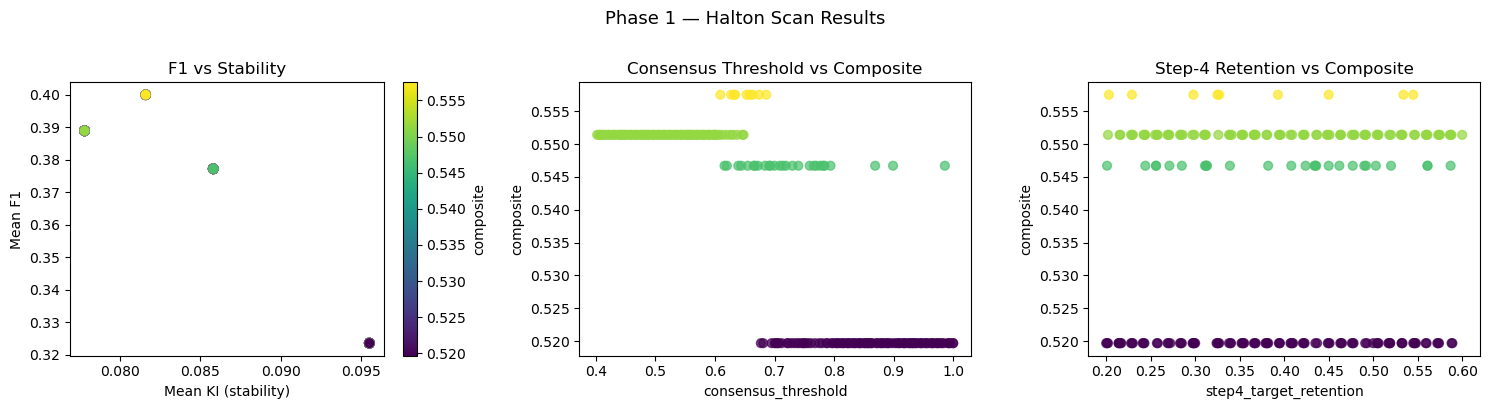


Parameter importance (Phase 1):


,parameter,spearman_r,p_value,|r|
0,consensus_threshold,-0.837,0.0000,0.837
2,n_consensus_models,0.087,0.2178,0.087
4,l1_upper,0.045,0.5197,0.045
7,shap_upper,-0.038,0.5854,0.038
8,step3_target_retention,0.038,0.5893,0.038
9,step4_target_retention,0.026,0.7119,0.026
3,quick_tune_iterations,0.020,0.7749,0.020
1,stability_threshold,-0.016,0.8219,0.016
5,l2_upper,-0.002,0.9722,0.002
6,rfecv_upper,0.002,0.9814,0.002


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sc = axes[0].scatter(
    agg_p1['mean_ki'], agg_p1['mean_f1'],
    c=agg_p1['composite'], cmap='viridis', s=55, edgecolors='grey', lw=0.3
)
plt.colorbar(sc, ax=axes[0], label='composite')
axes[0].set_xlabel('Mean KI (stability)')
axes[0].set_ylabel('Mean F1')
axes[0].set_title('F1 vs Stability')

axes[1].scatter(agg_p1['consensus_threshold'], agg_p1['composite'],
                c=agg_p1['composite'], cmap='viridis', s=40, alpha=0.7)
axes[1].set_xlabel('consensus_threshold')
axes[1].set_ylabel('composite')
axes[1].set_title('Consensus Threshold vs Composite')

axes[2].scatter(agg_p1['step4_target_retention'], agg_p1['composite'],
                c=agg_p1['composite'], cmap='viridis', s=40, alpha=0.7)
axes[2].set_xlabel('step4_target_retention')
axes[2].set_ylabel('composite')
axes[2].set_title('Step-4 Retention vs Composite')

plt.suptitle('Phase 1, Halton Scan Results', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'phase1_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

param_cols = [k for k in PARAM_SPACE if k in agg_p1.columns]
corr_rows = []
for p in param_cols:
    mask = agg_p1[p].notna()
    r, pv = spearmanr(agg_p1.loc[mask, p], agg_p1.loc[mask, 'composite'])
    corr_rows.append({'parameter': p, 'spearman_r': round(r, 3),
                      'p_value': round(pv, 4), '|r|': round(abs(r), 3)})
print('\nParameter importance (Phase 1):')
display(pd.DataFrame(corr_rows).sort_values('|r|', ascending=False))


---
## Phase 2, Multi-Scenario Check

Validates the top `N_PHASE2_TOP` Phase-1 configs on **3 representative scenarios**:
`omics_tiny_n`, `omics_standard`, and `adversarial_easy`.

This filters out configs that scored well on `omics_tiny_n` by chance but
don't generalise.  Five seeds give a more reliable estimate of variance before
the expensive Phase 3 run.

**Estimated runtime**: top-30 × 3 scenarios × 5 seeds ≈ 6–12 h.


In [16]:
_P2_CSV = OUTPUT_DIR / 'phase2_raw.csv'

_p2_top_names     = agg_p1.head(N_PHASE2_TOP)['config'].tolist()
_p2_all_names     = list(dict.fromkeys(list(BASELINE_CONFIGS) + _p2_top_names))
_p1_lookup        = dict(trial_list_phase1)
trial_list_phase2 = [(n, _p1_lookup[n]) for n in _p2_all_names if n in _p1_lookup]

print(f'Phase 2 configs : {len(trial_list_phase2)}')
print(f'Scenarios       : {[s.name for s in PHASE2_SCENARIOS]}')

if RUN_PHASE2:
    df_p2 = run_optimization_scan(
        trial_list_phase2, PHASE2_SCENARIOS, SEEDS_FULL,
        save_path=_P2_CSV, phase_label='Phase 2',
    )
else:
    if not _P2_CSV.exists():
        raise FileNotFoundError(f'{_P2_CSV} not found. Set RUN_PHASE2=True.')
    df_p2 = pd.read_csv(_P2_CSV)
    print(f'Loaded {len(df_p2)} rows from {_P2_CSV}')

print(f'\nPhase 2 rows : {len(df_p2)}')
print(f'Success rate : {(df_p2["status"] == "ok").mean():.1%}')


Phase 2 configs : 34
Scenarios       : ['omics_standard', 'omics_tiny_n', 'adversarial_easy']
  Resume: 510 existing rows in phase2_raw.csv
[Phase 2] Resuming, 510/510 evals already done (100%)

[Phase 2] Done, 510 rows, 0 errors.

Phase 2 rows : 510
Success rate : 100.0%


In [17]:
agg_p2 = aggregate_configs(df_p2)
print('Phase 2, configs ranked by composite (3 representative scenarios)')
display(
    agg_p2[['config', 'composite', 'mean_f1', 'mean_ki', 'mean_auc', 'n_sel_mean']]
    .style.background_gradient(cmap='viridis', subset=['composite', 'mean_f1', 'mean_ki'], axis=0)
    .format('{:.3f}', subset=['composite', 'mean_f1', 'mean_ki', 'mean_auc'])
)

print('\nMean F1 per config × scenario:')
_f1p2 = (
    df_p2.groupby(['config', 'scenario'])['f1'].mean()
         .unstack('scenario').round(3)
)
_f1p2['MEAN'] = _f1p2.mean(axis=1)
display(
    _f1p2.sort_values('MEAN', ascending=False)
         .style.background_gradient(cmap='viridis', axis=None).format('{:.3f}')
)


Phase 2, configs ranked by composite (3 representative scenarios)


,config,composite,mean_f1,mean_ki,mean_auc,n_sel_mean
0,h_093,0.593,0.413,0.252,0.994,9.500000
1,h_013,0.586,0.404,0.234,0.994,9.700000
2,h_161,0.584,0.401,0.235,0.993,10.500000
3,h_051,0.584,0.400,0.234,0.993,10.700000
4,h_067,0.584,0.400,0.234,0.994,11.200000
5,h_071,0.583,0.399,0.232,0.993,10.400000
6,h_065,0.582,0.398,0.228,0.994,10.900000
7,h_091,0.581,0.396,0.228,0.993,10.100000
8,h_107,0.581,0.397,0.224,0.994,10.600000
9,omics_tuned,0.579,0.395,0.219,0.992,10.400000



Mean F1 per config × scenario:


scenario,adversarial_easy,omics_standard,omics_tiny_n,MEAN
config,,,,
h_093,0.068,0.791,0.380,0.413
h_013,0.069,0.762,0.380,0.404
h_161,0.065,0.763,0.373,0.400
h_051,0.064,0.763,0.373,0.400
h_067,0.062,0.770,0.366,0.399
h_071,0.065,0.758,0.373,0.399
h_065,0.063,0.756,0.373,0.397
h_107,0.065,0.751,0.373,0.396
h_091,0.065,0.750,0.373,0.396


---
## Phase 3, Full Development-Scenario Validation

Validates the top `N_PHASE3_TOP` Phase-2 configs across **all 6 development
scenarios** with 5 seeds.  This is the most comprehensive ranking.

**Estimated runtime**: top-15 × 6 scenarios × 5 seeds ≈ 12–25 h.


In [19]:
_P3_CSV = OUTPUT_DIR / 'phase3_raw.csv'

_p3_top_names     = agg_p2.head(N_PHASE3_TOP)['config'].tolist()
_p3_all_names     = list(dict.fromkeys(list(BASELINE_CONFIGS) + _p3_top_names))
_p2_lookup        = dict(trial_list_phase2)
_p12_lookup       = {**_p1_lookup, **_p2_lookup}
trial_list_phase3 = [(n, _p12_lookup[n]) for n in _p3_all_names if n in _p12_lookup]

print(f'Phase 3 configs : {len(trial_list_phase3)}')
print(f'Scenarios       : {[s.name for s in PHASE34_SCENARIOS]}')

if RUN_PHASE3:
    df_p3 = run_optimization_scan(
        trial_list_phase3, PHASE34_SCENARIOS, SEEDS_FULL,
        save_path=_P3_CSV, phase_label='Phase 3',
    )
else:
    if not _P3_CSV.exists():
        raise FileNotFoundError(f'{_P3_CSV} not found. Set RUN_PHASE3=True.')
    df_p3 = pd.read_csv(_P3_CSV)
    print(f'Loaded {len(df_p3)} rows from {_P3_CSV}')

print(f'\nPhase 3 rows : {len(df_p3)}')
print(f'Success rate : {(df_p3["status"] == "ok").mean():.1%}')


Phase 3 configs : 18
Scenarios       : ['omics_standard', 'omics_tiny_n', 'omics_high_dim', 'omics_imbalanced', 'omics_genomics', 'adversarial_easy']
  Resume: 540 existing rows in phase3_raw.csv
[Phase 3] Resuming, 540/540 evals already done (100%)

[Phase 3] Done, 540 rows, 0 errors.

Phase 3 rows : 540
Success rate : 100.0%


In [20]:
agg_p3 = aggregate_configs(df_p3)
print('Phase 3, all 6 development scenarios, ranked by composite')
display(
    agg_p3[['config', 'composite', 'mean_f1', 'mean_ki', 'mean_auc',
            'n_sel_mean', 'elapsed_mean']]
    .style.background_gradient(cmap='viridis', subset=['composite', 'mean_f1', 'mean_ki'], axis=0)
    .format('{:.3f}', subset=['composite', 'mean_f1', 'mean_ki', 'mean_auc'])
)

_f1p3 = (
    df_p3.groupby(['config', 'scenario'])['f1']
         .mean().unstack('scenario').round(3)
         .reindex(agg_p3['config'].tolist())
)
_f1p3['MEAN'] = _f1p3.mean(axis=1)
display(
    _f1p3.style.background_gradient(cmap='viridis', axis=None).format('{:.3f}')
)


Phase 3, all 6 development scenarios, ranked by composite


,config,composite,mean_f1,mean_ki,mean_auc,n_sel_mean,elapsed_mean
0,h_071,0.716,0.599,0.449,0.995,10.200000,518.000000
1,h_161,0.713,0.595,0.446,0.995,10.500000,518.300000
2,h_053,0.711,0.593,0.434,0.995,10.600000,753.500000
3,h_107,0.710,0.592,0.436,0.995,10.500000,684.200000
4,h_197,0.709,0.591,0.430,0.995,10.800000,655.000000
5,h_179,0.706,0.586,0.429,0.994,11.000000,398.100000
6,h_093,0.702,0.582,0.415,0.995,9.800000,795.200000
7,h_091,0.702,0.581,0.418,0.995,9.800000,502.600000
8,h_065,0.690,0.565,0.390,0.995,12.300000,440.800000
9,h_149,0.690,0.565,0.388,0.994,10.200000,406.300000


scenario,adversarial_easy,omics_genomics,omics_high_dim,omics_imbalanced,omics_standard,omics_tiny_n,MEAN
config,,,,,,,
h_071,0.065,1.000,0.610,0.786,0.758,0.373,0.599
h_161,0.065,1.000,0.580,0.789,0.763,0.373,0.595
h_053,0.068,1.000,0.624,0.774,0.711,0.380,0.593
h_107,0.065,1.000,0.586,0.775,0.751,0.373,0.592
h_197,0.066,0.980,0.631,0.780,0.707,0.380,0.591
h_179,0.059,1.000,0.562,0.777,0.743,0.373,0.586
h_093,0.068,0.882,0.636,0.737,0.791,0.380,0.582
h_091,0.065,0.900,0.641,0.758,0.750,0.373,0.581
h_065,0.063,0.856,0.567,0.777,0.756,0.373,0.565


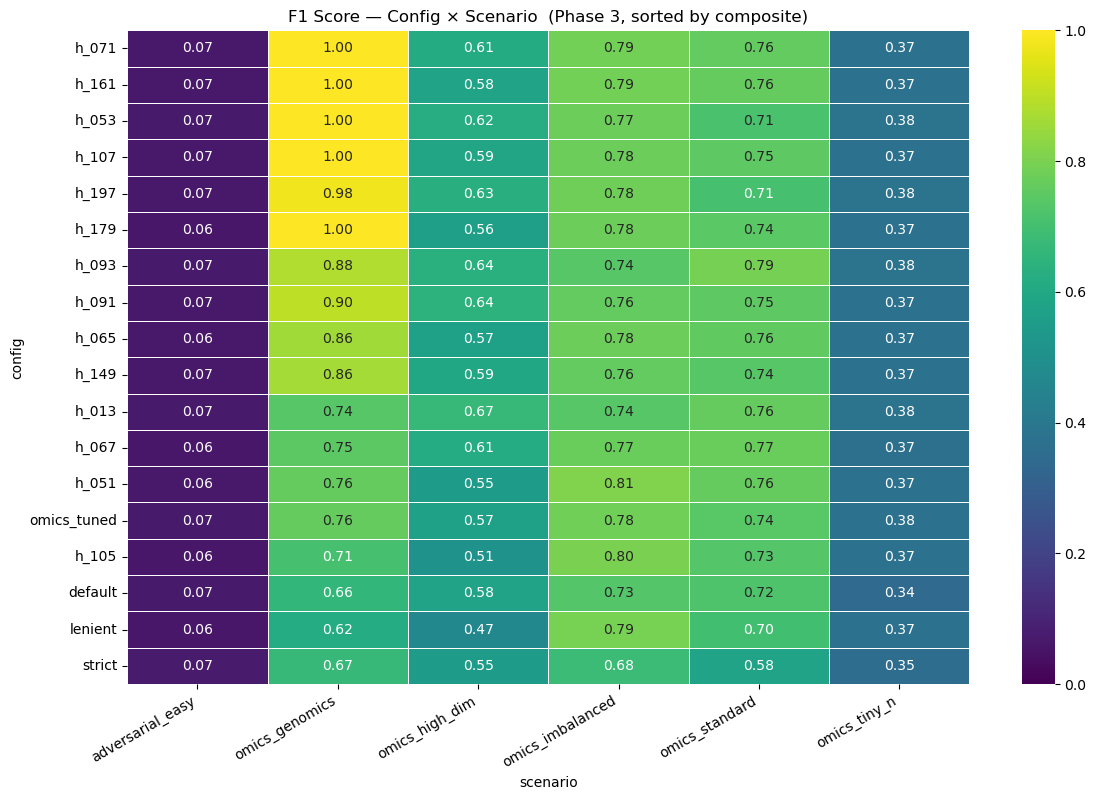

In [21]:
fig, ax = plt.subplots(figsize=(12, max(4, len(agg_p3) * 0.45)))
_heat3 = (
    df_p3.groupby(['config', 'scenario'])['f1']
         .mean().unstack('scenario').round(3)
         .reindex(agg_p3['config'].tolist())
)
sns.heatmap(_heat3, annot=True, fmt='.2f', cmap='viridis',
            vmin=0, vmax=1, linewidths=0.4, ax=ax)
ax.set_title('F1 Score, Config × Scenario  (Phase 3, sorted by composite)', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'phase3_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Phase 4, Neighbourhood Refinement

Takes the top `N_PHASE4_TOP` Phase-3 configs and generates `N_PHASE4_PERTURB`
Gaussian perturbations of each.  All neighbours are validated on all 6
development scenarios with 5 seeds.

This exploits the structure found by Phase 3 without another full scan.

**Estimated runtime**: 5 × 20 perturbations × 6 scenarios × 5 seeds ≈ 10–20 h.


In [23]:
_PHASE4_RNG = np.random.RandomState(RANDOM_SEED + 42)
_p3_winners = agg_p3.head(N_PHASE4_TOP)

_p3_param_lkp = {
    row['config']: {k: row[k] for k in PARAM_SPACE if k in row.index}
    for _, row in _p3_winners.iterrows()
}

trial_list_phase4 = []
for parent_name, parent_params in _p3_param_lkp.items():
    for j, nb_params in enumerate(
        generate_neighbours(parent_params, N_PHASE4_PERTURB, _PHASE4_RNG)
    ):
        trial_list_phase4.append((f'n_{parent_name[:10]}_{j:02d}', nb_params))

print(f'Phase 4 neighbour configs : {len(trial_list_phase4)}')
print(f'  {N_PHASE4_TOP} parent configs × {N_PHASE4_PERTURB} perturbations each')


Phase 4 neighbour configs : 100
  5 parent configs × 20 perturbations each


In [ ]:
_P4_CSV = OUTPUT_DIR / 'phase4_raw.csv'

if RUN_PHASE4:
    df_p4 = run_optimization_scan(
        trial_list_phase4, PHASE34_SCENARIOS, SEEDS_FULL,
        save_path=_P4_CSV, phase_label='Phase 4',
    )
else:
    if not _P4_CSV.exists():
        raise FileNotFoundError(f'{_P4_CSV} not found. Set RUN_PHASE4=True.')
    df_p4 = pd.read_csv(_P4_CSV)
    print(f'Loaded {len(df_p4)} rows from {_P4_CSV}')

print(f'\nPhase 4 rows : {len(df_p4)}')
print(f'Success rate : {(df_p4["status"] == "ok").mean():.1%}')


  Resume: 470 existing rows in phase4_raw.csv
[Phase 4] Resuming, 470/3000 evals already done (16%)
  [ 941/3000]  n_h_071_15              omics_genomics          seed=0  F1=1.000  n_sel=   10  (2265s)
  [ 942/3000]  n_h_071_15              omics_genomics          seed=1  F1=1.000  n_sel=   10  (2278s)
  [ 943/3000]  n_h_071_15              omics_genomics          seed=2  F1=1.000  n_sel=   10  (2362s)
  [ 944/3000]  n_h_071_15              omics_genomics          seed=3  F1=1.000  n_sel=   10  (2205s)
  [ 945/3000]  n_h_071_15              omics_genomics          seed=4  F1=0.818  n_sel=   12  (2496s)
  [ 946/3000]  n_h_071_15              adversarial_easy        seed=0  F1=0.065  n_sel=   11  (86s)
  [ 947/3000]  n_h_071_15              adversarial_easy        seed=1  F1=0.067  n_sel=   10  (120s)
  [ 948/3000]  n_h_071_15              adversarial_easy        seed=2  F1=0.059  n_sel=   14  (111s)
  [ 949/3000]  n_h_071_15              adversarial_easy        seed=3  F1=0.067  n_sel= 

In [ ]:
agg_p4 = aggregate_configs(df_p4)

# Combine Phase 3 originals + Phase 4 neighbours
df_combined  = pd.concat([df_p3, df_p4], ignore_index=True)
agg_combined = aggregate_configs(df_combined)

print('Combined Phase 3 + Phase 4, top 20 configs overall')
display(
    agg_combined.head(20)[['config', 'composite', 'mean_f1', 'mean_ki', 'mean_auc', 'n_sel_mean']]
    .style.background_gradient(cmap='viridis', subset=['composite', 'mean_f1', 'mean_ki'], axis=0)
    .format('{:.3f}', subset=['composite', 'mean_f1', 'mean_ki', 'mean_auc'])
)

_delta = agg_combined.iloc[0]['composite'] - agg_p3.iloc[0]['composite']
print(f'\nPhase 3 best : {agg_p3.iloc[0]["composite"]:.4f}  ({agg_p3.iloc[0]["config"]})')
print(f'Combined best: {agg_combined.iloc[0]["composite"]:.4f}  ({agg_combined.iloc[0]["config"]})')
print(f'Improvement  : {_delta:+.4f}')


In [ ]:
best_row    = agg_combined.iloc[0]
best_name   = best_row['config']
best_params = {k: best_row[k] for k in PARAM_SPACE if k in best_row.index}

default_row = agg_combined[agg_combined['config'] == 'default']

print('=' * 68)
print(f'RECOMMENDED CONFIG : {best_name}')
print('=' * 68)
for k, v in best_params.items():
    default_v = BASELINE_CONFIGS['default'].get(k, '?')
    changed   = '  <-- CHANGED' if str(v) != str(default_v) else ''
    print(f'  {k:35s}  {str(v):8s}  (default: {default_v}){changed}')

print()
print(f'Composite : {best_row["composite"]:.4f}')
print(f'Mean F1   : {best_row["mean_f1"]:.4f}')
print(f'Mean KI   : {best_row["mean_ki"]:.4f}')
print(f'Mean AUC  : {best_row["mean_auc"]:.4f}')
if not default_row.empty:
    d = default_row.iloc[0]
    print(f'\nVs default: F1 {best_row["mean_f1"]-d["mean_f1"]:+.4f}, '
          f'KI {best_row["mean_ki"]-d["mean_ki"]:+.4f}, '
          f'composite {best_row["composite"]-d["composite"]:+.4f}')


In [ ]:
recommended = {
    'source_notebook':    'SelectOmics_Config_Optimization.ipynb',
    'phase1_scenarios':   [s.name for s in PHASE1_SCENARIOS],
    'phase2_scenarios':   [s.name for s in PHASE2_SCENARIOS],
    'phase34_scenarios':  [s.name for s in PHASE34_SCENARIOS],
    'objective_weights':  {'f1': 0.50, 'ki': 0.30, 'auc': 0.20},
    'n_phase1_trials':    N_PHASE1_TRIALS,
    'n_phase4_perturb':   N_PHASE4_PERTURB,
    'random_seed':        RANDOM_SEED,
    'winning_config':     best_name,
    'metrics': {
        'composite': float(best_row['composite']),
        'mean_f1':   float(best_row['mean_f1']),
        'mean_ki':   float(best_row['mean_ki']),
        'mean_auc':  float(best_row['mean_auc']),
    },
    'params': {
        k: (float(v) if isinstance(v, (float, np.floating)) else int(v))
        for k, v in best_params.items()
    },
}

out_json = OUTPUT_DIR / 'selectomics_recommended_config.json'
with open(out_json, 'w') as f:
    json.dump(recommended, f, indent=2)
print(f'Recommended config saved -> {out_json}')

print('\n# ── Paste into SelectOmicsMultiStepSelector._build_config:')
print('# opt_params = {')
for k, v in best_params.items():
    print(f'#     {repr(k)}: {repr(v)},')
print('# }')


In [ ]:
if len(agg_combined) >= 5:
    param_cols_c = [k for k in PARAM_SPACE if k in agg_combined.columns]
    sens_rows = []
    for p in param_cols_c:
        mask = agg_combined[p].notna()
        if mask.sum() < 4:
            continue
        r, pv = spearmanr(agg_combined.loc[mask, p], agg_combined.loc[mask, 'composite'])
        sens_rows.append({'parameter': p, 'spearman_r': round(r, 3),
                          'p_value': round(pv, 4), '|r|': round(abs(r), 3)})

    if sens_rows:
        sens_df = pd.DataFrame(sens_rows).sort_values('|r|', ascending=False)
        _cmap   = plt.cm.viridis
        _cols   = [_cmap(0.8) if r >= 0 else _cmap(0.2) for r in sens_df['spearman_r']]

        fig, ax = plt.subplots(figsize=(7, max(3, len(sens_df) * 0.45)))
        ax.barh(sens_df['parameter'], sens_df['spearman_r'], color=_cols)
        ax.axvline(0, color='black', lw=0.8)
        ax.set_xlabel('Spearman r  (with composite score)', fontsize=11)
        ax.set_title('Parameter Sensitivity, Combined Phase 3+4', fontsize=13)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'sensitivity.png', dpi=150)
        plt.show()

        print('Positive r = higher value → higher composite')
        print('Negative r = lower value  → higher composite')
        display(sens_df)
else:
    print('Not enough configs for sensitivity analysis.')
